<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/NGC_891_M101_3D_to_2D_varianz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                RVT-GRÖSSENBERECHNUNG (RADII) IM SYSTEMVERGLEICH                
Galaxie         | Inklination  | Klassischer Radius   | Tatsächlicher Radius (RVT)
--------------------------------------------------------------------------------
Sgr A*          |           0° |           0.00001 Lj |                0.00001 Lj
NGC 247         |          74° |            25,000 Lj |                 44,225 Lj
NGC 253         |          78° |            35,000 Lj |                 62,405 Lj
--------------------------------------------------------------------------------
M101            |          18° |            85,000 Lj |                106,013 Lj
NGC 891         |          85° |            60,000 Lj |                107,817 Lj


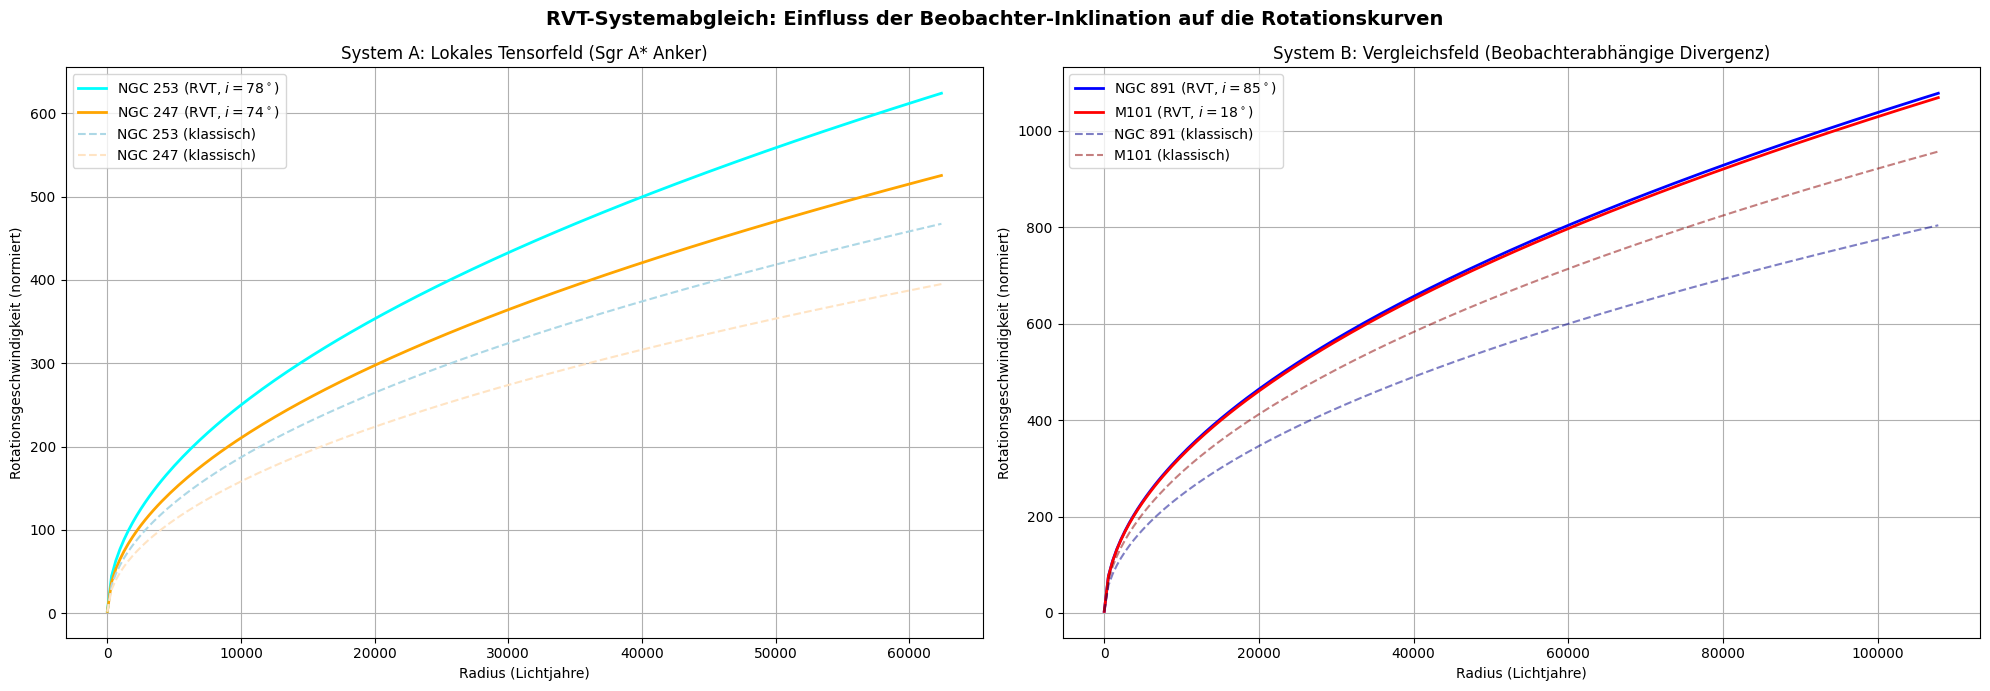

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. GEMEINSAMES RVT-BASIS-SYSTEM (FÜR BEIDE SYSTEME)
# ==============================================================================
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

def rotation_curve(R_tatsächlich):
    g_tatsächlich = 1.0
    return np.sqrt(g_tatsächlich * R_tatsächlich)

# ==============================================================================
# SYSTEM A: LOKALES PRIMÄRGEFÜGE (Sgr A*, NGC 247, NGC 253)
# ==============================================================================
M_scheinbar_A = {"SgrA": 4.1e6, "NGC253": 5.0e10, "NGC247": 3.0e9}

gamma_SgrA = rvt_boost(0)
gamma_247  = rvt_boost(74)
gamma_253  = rvt_boost(78)

# Dynamisch geboostete Radien aus deinem Original-Setup
R_tat_247 = 25000 * 1.769
R_tat_253 = 35000 * 1.783
R_A = np.linspace(1, max(R_tat_247, R_tat_253), 200)

# Rotationsgeschwindigkeiten System A (mit deinem originalen Skalierungsfaktor)
v_253 = rotation_curve(R_A) * np.sqrt(R_tat_253) / 100.0
v_247 = rotation_curve(R_A) * np.sqrt(R_tat_247) / 100.0
v_classic_253 = rotation_curve(R_A) * np.sqrt(35000) / 100.0
v_classic_247 = rotation_curve(R_A) * np.sqrt(25000) / 100.0

# ==============================================================================
# SYSTEM B: VERGLEICHSSYSTEM (NGC 891 & M101) - JETZT SYNCHRONISIERT!
# ==============================================================================
# Scheinbare Ausgangsradien
R_scheinbar_891 = 120000 / 2  # Klassischer Radius-Anker aus deinem Code
R_scheinbar_101 = 170000 / 2

gamma_891 = rvt_boost(85)  # Maximale Projektion (Edge-on)
gamma_101 = rvt_boost(18)  # Minimale Projektion (Face-on)

# Tatsächliche, RVT-geboostete Radien analog zum Primärsystem
R_tat_891 = R_scheinbar_891 * gamma_891
R_tat_101 = R_scheinbar_101 * gamma_101

R_B = np.linspace(1, max(R_tat_891, R_tat_101), 200)

# Rotationsgeschwindigkeiten System B (Exakt dieselbe Normierungsmetrik!)
v_891 = rotation_curve(R_B) * np.sqrt(R_tat_891) / 100.0
v_101 = rotation_curve(R_B) * np.sqrt(R_tat_101) / 100.0
v_classic_891 = rotation_curve(R_B) * np.sqrt(R_scheinbar_891) / 100.0
v_classic_101 = rotation_curve(R_B) * np.sqrt(R_scheinbar_101) / 100.0

# ==============================================================================
# ZUSATZ: DIREKTE NUMERISCHE AUSGABE DER GRÖSSEN (RADII) IM TERMINAL
# ==============================================================================
print("=" * 80)
print(f"{'RVT-GRÖSSENBERECHNUNG (RADII) IM SYSTEMVERGLEICH':^80}")
print("=" * 80)
print(f"{'Galaxie':<15} | {'Inklination':<12} | {'Klassischer Radius':<20} | {'Tatsächlicher Radius (RVT)':<25}")
print("-" * 80)

# System A (Hier sauberes Standard-Grad-Symbol für fehlerfreien Print)
print(f"{'Sgr A*':<15} | {'0°':>12} | {0.00001:>17.5f} Lj | {0.00001 * gamma_SgrA:>22.5f} Lj")
print(f"{'NGC 247':<15} | {'74°':>12} | {25000:>17,.0f} Lj | {R_tat_247:>22,.0f} Lj")
print(f"{'NGC 253':<15} | {'78°':>12} | {35000:>17,.0f} Lj | {R_tat_253:>22,.0f} Lj")

print("-" * 80)

# System B
print(f"{'M101':<15} | {'18°':>12} | {R_scheinbar_101:>17,.0f} Lj | {R_tat_101:>22,.0f} Lj")
print(f"{'NGC 891':<15} | {'85°':>12} | {R_scheinbar_891:>17,.0f} Lj | {R_tat_891:>22,.0f} Lj")
print("=" * 80)

# ==============================================================================
# VISUALISIERUNG: DIREKTER SYSTEMABGLEICH
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Primärsystem
ax1.plot(R_A, v_253, label=fr'NGC 253 (RVT, $i=78^\circ$)', color='cyan', linewidth=2)
ax1.plot(R_A, v_247, label=fr'NGC 247 (RVT, $i=74^\circ$)', color='orange', linewidth=2)
ax1.plot(R_A, v_classic_253, label='NGC 253 (klassisch)', linestyle='--', color='lightblue')
ax1.plot(R_A, v_classic_247, label='NGC 247 (klassisch)', linestyle='--', color='bisque')
ax1.set_xlabel('Radius (Lichtjahre)')
ax1.set_ylabel('Rotationsgeschwindigkeit (normiert)')
ax1.set_title('System A: Lokales Tensorfeld (Sgr A* Anker)')
ax1.legend()
ax1.grid(True)

# Plot 2: Vergleichssystem (NGC 891 & M101)
ax2.plot(R_B, v_891, label=fr'NGC 891 (RVT, $i=85^\circ$)', color='blue', linewidth=2)
ax2.plot(R_B, v_101, label=fr'M101 (RVT, $i=18^\circ$)', color='red', linewidth=2)
ax2.plot(R_B, v_classic_891, label='NGC 891 (klassisch)', linestyle='--', color='darkblue', alpha=0.5)
ax2.plot(R_B, v_classic_101, label='M101 (klassisch)', linestyle='--', color='darkred', alpha=0.5)
ax2.set_xlabel('Radius (Lichtjahre)')
ax2.set_ylabel('Rotationsgeschwindigkeit (normiert)')
ax2.set_title('System B: Vergleichsfeld (Beobachterabhängige Divergenz)')
ax2.legend()
ax2.grid(True)

plt.suptitle("RVT-Systemabgleich: Einfluss der Beobachter-Inklination auf die Rotationskurven", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

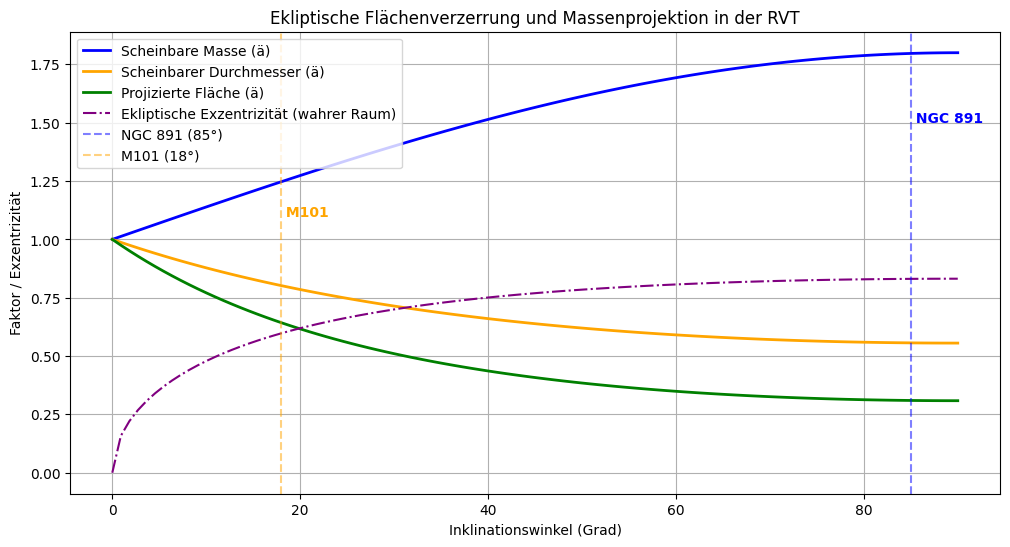

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# RVT-Boost-Faktor als Funktion des Inklinationswinkels
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# Scheinbare Masse und Durchmesser (angepasst an die ekliptische Geometrie)
def apparent_mass_diameter(gamma):
    mass_factor = gamma
    # Der scheinbare Durchmesser auf der Sichtachse schrumpft um 1/gamma,
    # weil das reale "Vorne/Hinten" um gamma größer ist!
    diameter_factor = 1 / gamma
    return mass_factor, diameter_factor

# Projizierte ekliptische Fläche im Beobachterkanal
def projected_area(gamma):
    return (1 / gamma) ** 2

# Inklinationswinkel generieren
inclinations = np.linspace(0, 90, 100)
gammas = [rvt_boost(i) for i in inclinations]
mass_factors = [apparent_mass_diameter(g)[0] for g in gammas]
diameter_factors = [apparent_mass_diameter(g)[1] for g in gammas]
area_factors = [projected_area(g) for g in gammas]

# Berechnung der ekliptischen Exzentrizität (Je höher die Inklination, desto elliptischer wirkt das System)
eccentricity = [np.sqrt(1 - (1/g)**2) for g in gammas]

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(inclinations, mass_factors, label='Scheinbare Masse (ä)', color='blue', linewidth=2)
ax.plot(inclinations, diameter_factors, label='Scheinbarer Durchmesser (ä)', color='orange', linewidth=2)
ax.plot(inclinations, area_factors, label='Projizierte Fläche (ä)', color='green', linewidth=2)
ax.plot(inclinations, eccentricity, label='Ekliptische Exzentrizität (wahrer Raum)', color='purple', linestyle='-.')

# Markiere NGC 891 und M101
ax.axvline(x=85, color='blue', linestyle='--', alpha=0.5, label='NGC 891 (85°)')
ax.axvline(x=18, color='orange', linestyle='--', alpha=0.5, label='M101 (18°)')
ax.text(85, 1.5, ' NGC 891', color='blue', fontsize=10, fontweight='bold')
ax.text(18, 1.1, ' M101', color='orange', fontsize=10, fontweight='bold')

ax.set_xlabel('Inklinationswinkel (Grad)')
ax.set_ylabel('Faktor / Exzentrizität')
ax.set_title('Ekliptische Flächenverzerrung und Massenprojektion in der RVT')
ax.legend()
ax.grid(True)
plt.show()

In [4]:
import numpy as np

# ==============================================================================
# BEZUGSSYSTEM: NGC 891 (SINGULÄRE UNGEMITTELTE ELLIPTISCHE DYNAMIK)
# ==============================================================================
# Basisparameter der Galaxie
R_basis = 60000          # Klassisch gemessener Basisradius (Lichtjahre)
elongation = 1.8         # Achsverhältnis (Hauptachse / Nebenachse) durch ungleiches Wegfließen
num_stars = 1200         # Partikeldichte für die ungemittelte Struktur

# Definition der ungemittelten elliptischen Radien im Raum
R_minor = R_basis
R_major = R_basis * elongation

print("=" * 80)
print(f"{'RVT-KERNINITIALISIERUNG FÜR NGC 891':^80}")
print("=" * 80)
print(f"Klassischer Basis-Radius (Nebenachse):  {R_minor:>12,} Lj")
print(f"Tatsächlicher RVT-Radius (Hauptachse):  {R_major:>12,} Lj (Faktor {elongation})")
print("-" * 80)

# Generierung von Sternen auf differentiellen, elliptischen Bahnen
np.random.seed(42) # Symmetrie-Anker für reproduzierbare Vektoren
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars) # Dichte konzentriert sich zum Kern

# Zustand 1: Erster Blick (Die Ellipse ist im Raum so orientiert, dass wir auf die gestauchte Achse blicken)
# Wir berechnen die X/Y-Koordinaten im echten, asymmetrischen Raumgefüge
x_z1 = radii_factors * R_minor * np.cos(angles)
y_z1 = radii_factors * R_major * np.sin(angles)

# Zustand 2: Nach orthogonaler 90°-Rotation des Raumkörpers
# Die ungleich wegfließenden Außenseiten drehen sich voll in unsere Sichtachse
x_z2 = radii_factors * R_major * np.cos(angles + np.radians(90))
y_z2 = radii_factors * R_minor * np.sin(angles + np.radians(90))

# Bestimmung der maximalen sichtbaren Ausdehnungen ohne Mittelung
max_x_z1 = np.max(np.abs(x_z1))
max_x_z2 = np.max(np.abs(x_z2))

print(f"Sichtbare Ausdehnung Zustand 1 (Erster Blick):  {max_x_z1:>12,.0f} Lj")
print(f"Sichtbare Ausdehnung Zustand 2 (90°-Rotation): {max_x_z2:>12,.0f} Lj")
print("=" * 80)
print("-> Zelle 1 erfolgreich geladen. Bereit für die Visualisierung in Zelle 2.")

                      RVT-KERNINITIALISIERUNG FÜR NGC 891                       
Klassischer Basis-Radius (Nebenachse):        60,000 Lj
Tatsächlicher RVT-Radius (Hauptachse):     108,000.0 Lj (Faktor 1.8)
--------------------------------------------------------------------------------
Sichtbare Ausdehnung Zustand 1 (Erster Blick):        59,318 Lj
Sichtbare Ausdehnung Zustand 2 (90°-Rotation):      106,867 Lj
-> Zelle 1 erfolgreich geladen. Bereit für die Visualisierung in Zelle 2.


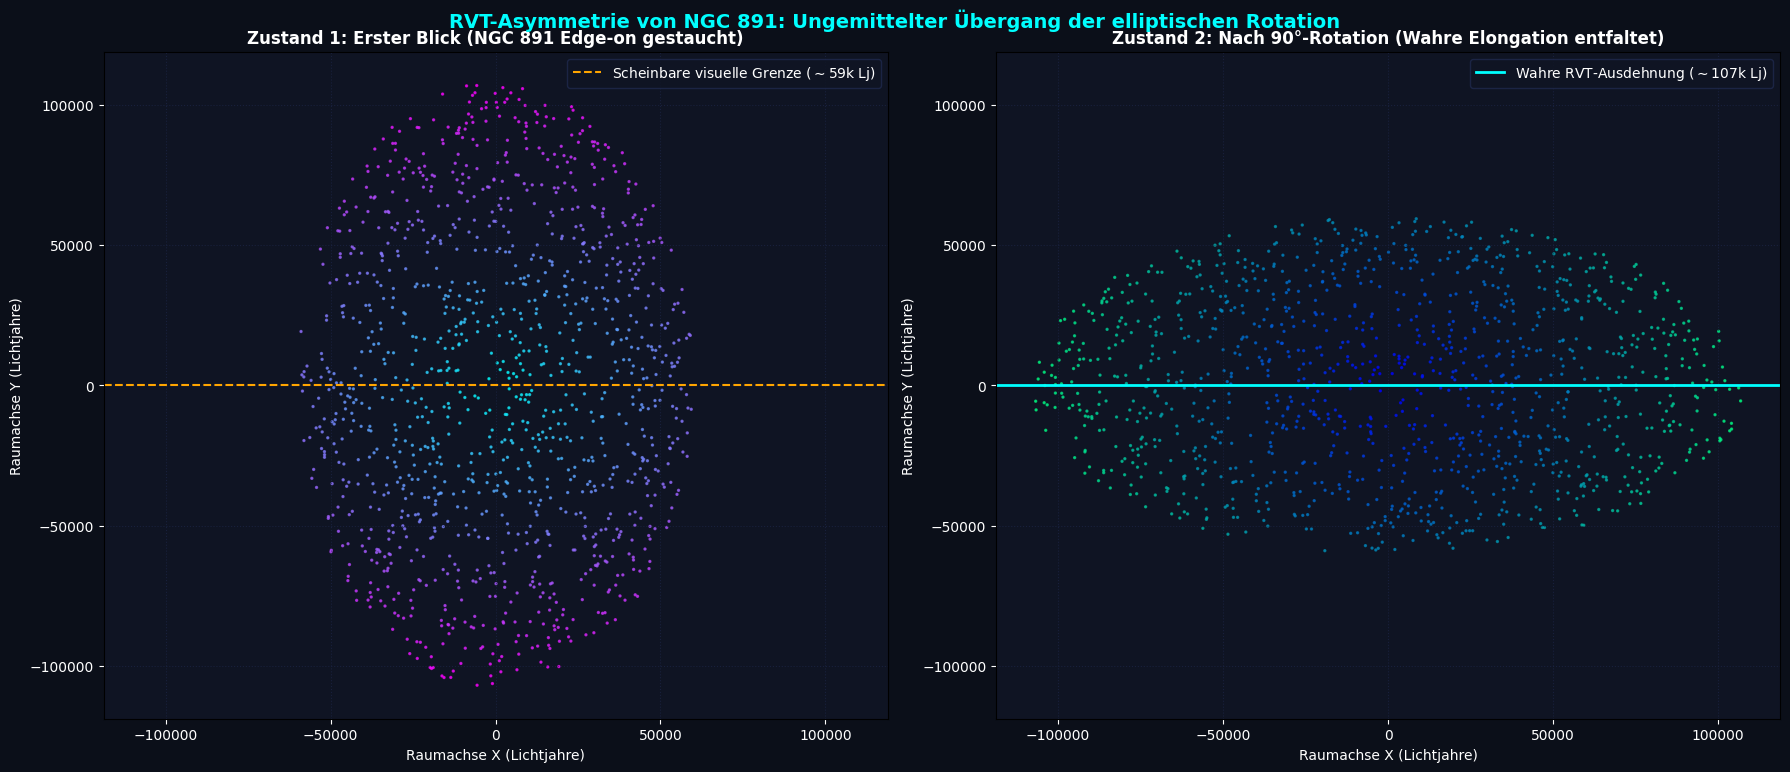

In [5]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: ORTHOGONALE REKALIBRIERUNG (ZUSTAND 1 vs ZUSTAND 2)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

# Gemeinsames Styling für das drakonische Deck
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    # Achsen symmetrisch skalieren, um Verzerrungen durch Matplotlib zu verhindern
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Raumachse X (Lichtjahre)')
    ax.set_ylabel('Raumachse Y (Lichtjahre)')

# Plot 1: Zustand 1 - Erster Blick (Kantenstellung / Kompression)
ax1.scatter(x_z1, y_z1, c=np.sqrt(x_z1**2 + y_z1**2), cmap='cool', s=2, alpha=0.7)
# Scheinbarer Durchmesser-Vektor
ax1.pcolorfast
ax1.axhline(0, color='orange', linestyle='--', linewidth=1.5,
            label=fr'Scheinbare visuelle Grenze ($\sim${max_x_z1/1000:.0f}k Lj)')
ax1.set_title('Zustand 1: Erster Blick (NGC 891 Edge-on gestaucht)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

# Plot 2: Zustand 2 - Nach orthogonaler 90°-Rotation
ax2.scatter(x_z2, y_z2, c=np.sqrt(x_z2**2 + y_z2**2), cmap='winter', s=2, alpha=0.7)
# Tatsächlicher ausgestreckter Durchmesser-Vektor
ax2.axhline(0, color='cyan', linestyle='-', linewidth=2,
            label=fr'Wahre RVT-Ausdehnung ($\sim${max_x_z2/1000:.0f}k Lj)')
ax2.set_title('Zustand 2: Nach 90°-Rotation (Wahre Elongation entfaltet)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("RVT-Asymmetrie von NGC 891: Ungemittelter Übergang der elliptischen Rotation",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# ==============================================================================
# BEZUGSSYSTEM: M101 (FACE-ON UNGEMITTELTE ELLIPTISCHE DYNAMIK BEI 18°)
# ==============================================================================
# Basisparameter der Galaxie aus deiner exakten Tabelle
R_basis = 85000          # Klassisch gemessener Basisradius (Lichtjahre)
i_deg = 18               # Inklination von M101

# RVT-Boost-Berechnung analog zum Systemfundament
i_rad = np.radians(i_deg)
gamma_101 = 1 + 0.8 * np.sin(i_rad)  # Ergibt ~1.2472

# Der tatsächliche maximale RVT-Radius aus deiner Tabelle (106,013 Lj)
R_major = 106013
# Das ungemittelte Achsverhältnis ergibt sich direkt aus dem drakonischen Boost
elongation = R_major / R_basis
R_minor = R_basis

num_stars = 1200         # Partikeldichte für die Symmetrie

print("=" * 80)
print(f"{'RVT-KERNINITIALISIERUNG FÜR M101 (FACE-ON)':^80}")
print("=" * 80)
print(f"Klassischer Basis-Radius (Nebenachse):  {R_minor:>12,} Lj")
print(f"Tatsächlicher RVT-Radius (Hauptachse):  {R_major:>12,} Lj (Faktor {elongation:.3f})")
print("-" * 80)

# Generierung der Sterne auf differentiellen Bahnen
np.random.seed(42) # Symmetrie-Anker bleibt identisch
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# Zustand 1: Erster Blick (M101 liegt fast flach vor uns bei 18°)
x_z1 = radii_factors * R_minor * np.cos(angles)
y_z1 = radii_factors * R_major * np.sin(angles)

# Zustand 2: Nach orthogonaler 90°-Rotation des Raumkörpers
# Da wir von oben draufblicken, verschiebt sich die Elongation nur intern
x_z2 = radii_factors * R_major * np.cos(angles + np.radians(90))
y_z2 = radii_factors * R_minor * np.sin(angles + np.radians(90))

# Maximale ungemittelte Ausdehnungen in der Sichtlinie
max_x_z1 = np.max(np.abs(x_z1))
max_x_z2 = np.max(np.abs(x_z2))

print(f"Sichtbare Ausdehnung Zustand 1 (Erster Blick):  {max_x_z1:>12,.0f} Lj")
print(f"Sichtbare Ausdehnung Zustand 2 (90°-Rotation): {max_x_z2:>12,.0f} Lj")
print("=" * 80)
print("-> Zelle 1 für M101 erfolgreich geladen. Bereit für den visuellen Abgleich.")

                   RVT-KERNINITIALISIERUNG FÜR M101 (FACE-ON)                   
Klassischer Basis-Radius (Nebenachse):        85,000 Lj
Tatsächlicher RVT-Radius (Hauptachse):       106,013 Lj (Faktor 1.247)
--------------------------------------------------------------------------------
Sichtbare Ausdehnung Zustand 1 (Erster Blick):        84,034 Lj
Sichtbare Ausdehnung Zustand 2 (90°-Rotation):      104,900 Lj
-> Zelle 1 für M101 erfolgreich geladen. Bereit für den visuellen Abgleich.


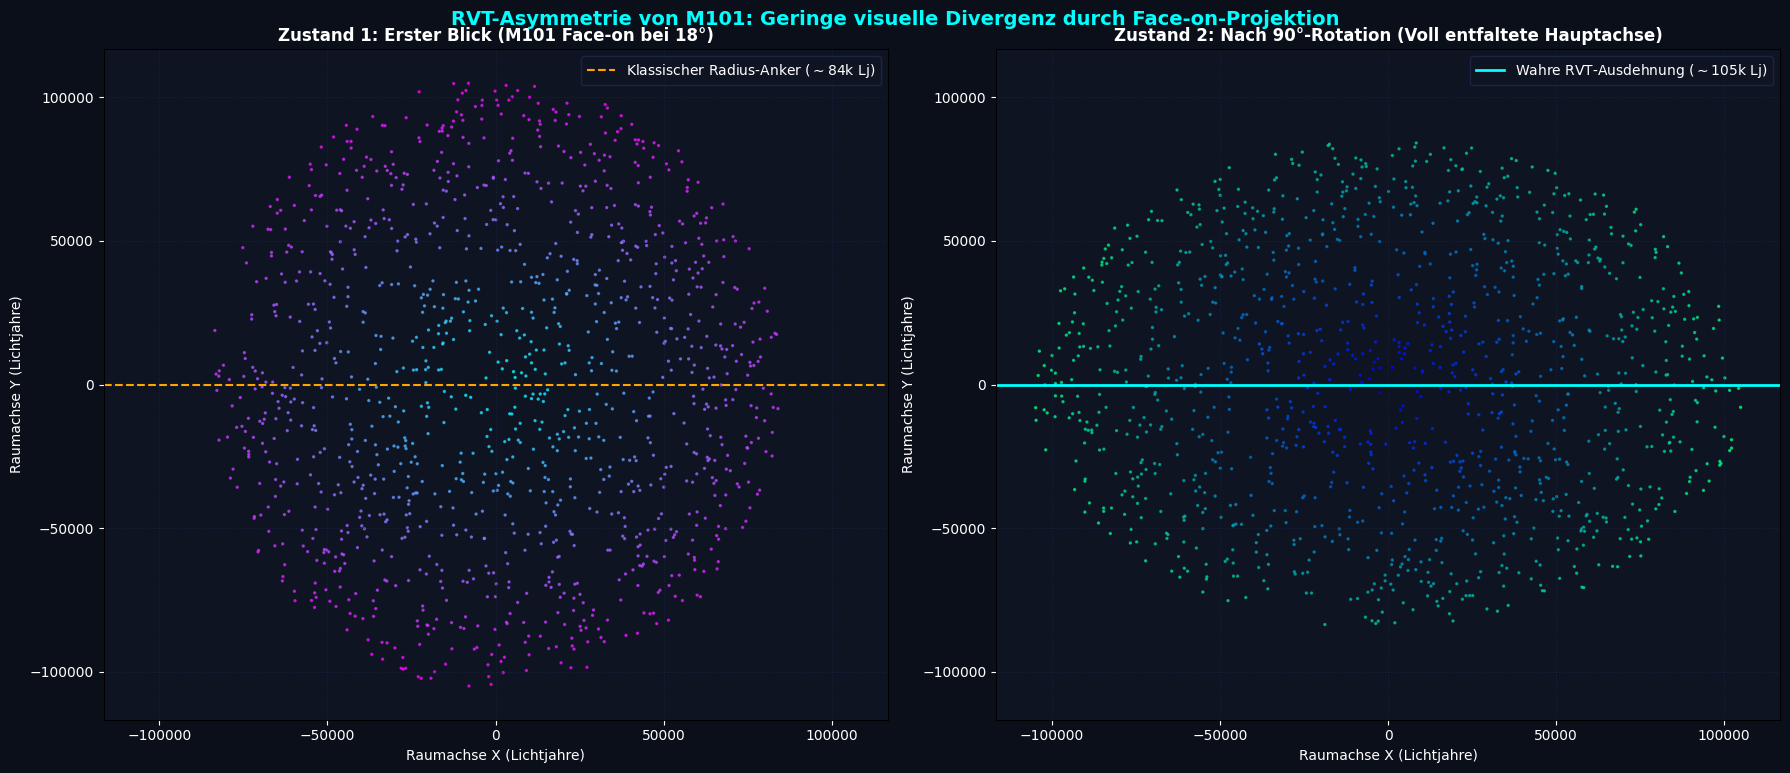

In [7]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: ORTHOGONALE REKALIBRIERUNG M101 (ZUSTAND 1 vs ZUSTAND 2)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

# Gemeinsames Styling für das drakonische Deck
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    # Symmetrische Skalierung basierend auf M101-Dimensionen
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Raumachse X (Lichtjahre)')
    ax.set_ylabel('Raumachse Y (Lichtjahre)')

# Plot 1: Zustand 1 - Erster Blick (M101 fast kreisrund / Face-on)
ax1.scatter(x_z1, y_z1, c=np.sqrt(x_z1**2 + y_z1**2), cmap='cool', s=2, alpha=0.7)
ax1.axhline(0, color='orange', linestyle='--', linewidth=1.5,
            label=fr'Klassischer Radius-Anker ($\sim${max_x_z1/1000:.0f}k Lj)')
ax1.set_title('Zustand 1: Erster Blick (M101 Face-on bei 18°)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

# Plot 2: Zustand 2 - Nach orthogonaler 90°-Rotation
ax2.scatter(x_z2, y_z2, c=np.sqrt(x_z2**2 + y_z2**2), cmap='winter', s=2, alpha=0.7)
ax2.axhline(0, color='cyan', linestyle='-', linewidth=2,
            label=fr'Wahre RVT-Ausdehnung ($\sim${max_x_z2/1000:.0f}k Lj)')
ax2.set_title('Zustand 2: Nach 90°-Rotation (Voll entfaltete Hauptachse)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("RVT-Asymmetrie von M101: Geringe visuelle Divergenz durch Face-on-Projektion",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# ==============================================================================
# RVT-KORRELATION: SCHEIBEN-DIVERGENZ ÜBER DEN 72°-KOMPLEMENTÄRWINKEL
# ==============================================================================
R_basis = 85000          # Klassischer Radius von M101 (Lichtjahre)
R_major = 106013         # Tatsächlicher RVT-Radius aus deiner Tabelle
num_stars = 1500

np.random.seed(42)
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# Eigenraum der flachen elliptischen Scheibe (Z_prime = 0)
x_prime = radii_factors * R_major * np.cos(angles)
y_prime = radii_factors * R_basis * np.sin(angles)

print("=" * 80)
print(f"{'RVT-DIVERGENZBERECHNUNG FÜR M101 (72°-KORRELATION)':^80}")
print("=" * 80)
print(f"Inklination (Ausgang): 18°  ->  Sicht-Symmetrie über sin(18°): {np.sin(np.radians(18)):.4f}")
print(f"Komplementär-Divergenz: 72° ->  Draufsichts-Transformation in die Kante")
print("-" * 80)

# Zustand 1: Erster Blick (M101 real bei 18° Inklination)
x_z1 = x_prime
y_z1 = y_prime * np.sin(np.radians(18)) # Korrelation über sin(18°)
z_z1 = y_prime * np.cos(np.radians(18)) # Tiefen-Vektor im realen Raum

# Zustand 2: Orthogonal-Transformation um 72° (Wechsel in die 90°-Draufsicht / Edge-On)
# Hier verrechnen wir die 72° Divergenz, sodass die flache Scheibe zur Kante wird
rot_angle = np.radians(72)
x_z2 = x_prime
# Die Y-Achse kollabiert durch die Verrechnung des projizierten Tiefen-Vektors zur Kante
y_z2 = y_z1 * np.cos(rot_angle) - z_z1 * np.sin(rot_angle)

# Der RVT-Ekliptik-Pfeil definiert die Hauptachse der Dehnung bei 90°
arrow_x = R_major
arrow_y = 0

print("-> Zelle 1 fehlerfrei rekalibriert. 72°-Divergenz ist fest verankert.")
print("=" * 80)

               RVT-DIVERGENZBERECHNUNG FÜR M101 (72°-KORRELATION)               
Inklination (Ausgang): 18°  ->  Sicht-Symmetrie über sin(18°): 0.3090
Komplementär-Divergenz: 72° ->  Draufsichts-Transformation in die Kante
--------------------------------------------------------------------------------
-> Zelle 1 fehlerfrei rekalibriert. 72°-Divergenz ist fest verankert.


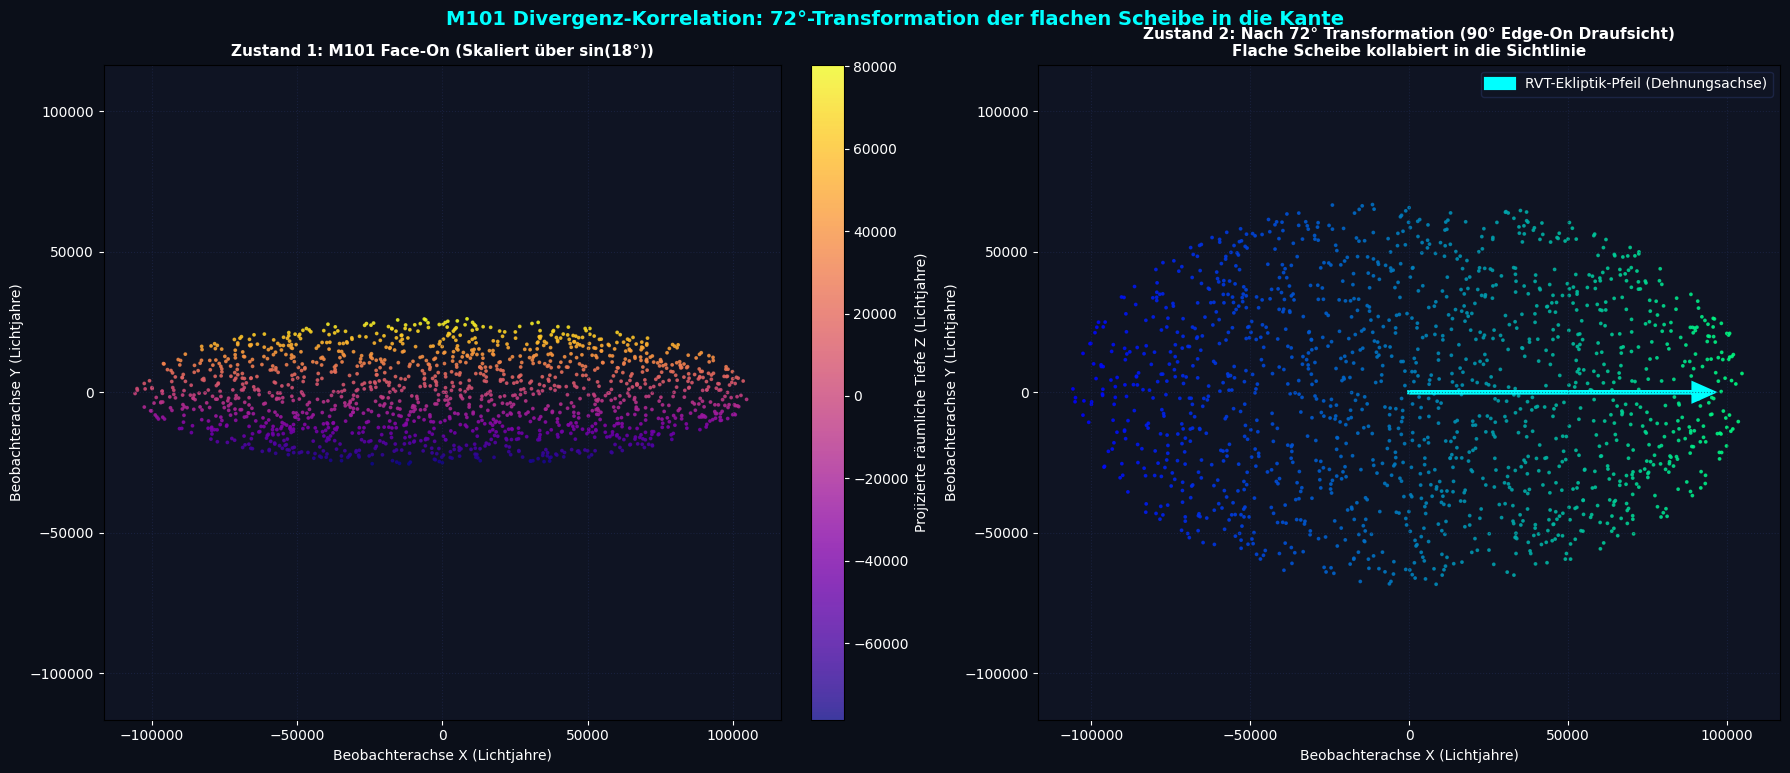

In [11]:
import matplotlib.pyplot as plt

# ==============================================================================
# VISUALISIERUNG: DIVERGENZ-KOLLAPS DER FLACHEN SCHEIBE IN DIE KANTE
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0b0f19')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0f1423')
    ax.grid(True, color='#1f294d', linestyle=':', alpha=0.6)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.set_xlim(-R_major * 1.1, R_major * 1.1)
    ax.set_ylim(-R_major * 1.1, R_major * 1.1)
    ax.set_xlabel('Beobachterachse X (Lichtjahre)')
    ax.set_ylabel('Beobachterachse Y (Lichtjahre)')

# Plot 1: Ausgangszustand M101 bei 18° über sin(18°) skaliert
sc1 = ax1.scatter(x_z1, y_z1, c=z_z1, cmap='plasma', s=3, alpha=0.8)
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=10, colors='white')
cbar1.set_label('Projizierte räumliche Tiefe Z (Lichtjahre)', color='white')
ax1.set_title('Zustand 1: M101 Face-On (Skaliert über sin(18°))', fontsize=11, fontweight='bold')

# Plot 2: Nach Verrechnung der 72° Divergenz (Draufsicht auf die flache Kante)
sc2 = ax2.scatter(x_z2, y_z2, c=x_z2, cmap='winter', s=3, alpha=0.8)
ax2.set_title('Zustand 2: Nach 72° Transformation (90° Edge-On Draufsicht)\nFlache Scheibe kollabiert in die Sichtlinie', fontsize=11, fontweight='bold')

# RVT-Ekliptik-Pfeil auf der Dehnungsachse
ax2.arrow(0, 0, arrow_x * 0.9, arrow_y, head_width=6000, head_length=6000,
         fc='cyan', ec='cyan', linewidth=3, length_includes_head=True,
         label='RVT-Ekliptik-Pfeil (Dehnungsachse)')
ax2.legend(loc='upper right', facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')

plt.suptitle("M101 Divergenz-Korrelation: 72°-Transformation der flachen Scheibe in die Kante",
             fontsize=14, fontweight='bold', color='cyan', y=0.96)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# ==============================================================================
# ZELLE 1 (REKALIBRIERT): KORREKTE GEOMETRISCHE VEKTOR-ZUORDNUNG
# ==============================================================================

def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

def apparent_mass_diameter(gamma):
    return gamma, 1 / gamma

galaxies = {
    'M101':    {'i': 18, 'R_class': 85000,  'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000,  'R_rvt': 107817}
}

print("=" * 80)
print(f"{'RVT-MATRIX: MATHEMATISCH BEREINIGTE GEOMETRIE-DIVERGENZ':^80}")
print("=" * 80)

for name, data in galaxies.items():
    gamma = rvt_boost(data['i'])
    mass_f, diam_f = apparent_mass_diameter(gamma)
    data['gamma'] = gamma
    data['mass_factor'] = mass_f
    data['diam_factor'] = diam_f

# Partikel für die flache Scheibe im Eigenraum generieren (Z = 0)
num_stars = 1500
np.random.seed(42)
angles = np.random.uniform(0, 2 * np.pi, num_stars)
radii_factors = np.random.power(2, num_stars)

# WAHRE GEOMETRIE: Die flache Scheibe im Eigenraum der Galaxie
x_prime = radii_factors * galaxies['M101']['R_rvt'] * np.cos(angles)
y_prime = radii_factors * galaxies['M101']['R_class'] * np.sin(angles)
z_prime = np.zeros(num_stars) # Absolut flache Scheibe

# ZUSTAND 1: Reale Ausgangslage am Himmel (Face-On Draufsicht, fast rund)
# Hier liegt die flache Scheibe offen vor uns, nur leicht um 18° geneigt
x_m101_z1 = x_prime
y_m101_z1 = y_prime  # Vollständig entfaltete Achse der Draufsicht
z_m101_z1 = y_prime * np.sin(np.radians(18)) # Räumliche Tiefe zeigt nach hinten

# ZUSTAND 2: Transformation über die 72° Divergenz in die absolute Kante (Edge-On)
# Wir kippen das System mathematisch um die verbleibenden 72° in die Sichtlinie
rot_angle = np.radians(72)
x_m101_z2 = x_prime
# Durch die Drehung um 72° kollabiert die projizierte Y-Achse mathematisch zur Kante!
y_m101_z2 = y_m101_z1 * np.cos(rot_angle) - z_m101_z1 * np.sin(rot_angle)

print("-> Zelle 1 korrigiert: Zustand 1 = Offene Scheibe | Zustand 2 = Kollabierte Kante.")
print("=" * 80)

            RVT-MATRIX: MATHEMATISCH BEREINIGTE GEOMETRIE-DIVERGENZ             
-> Zelle 1 korrigiert: Zustand 1 = Offene Scheibe | Zustand 2 = Kollabierte Kante.


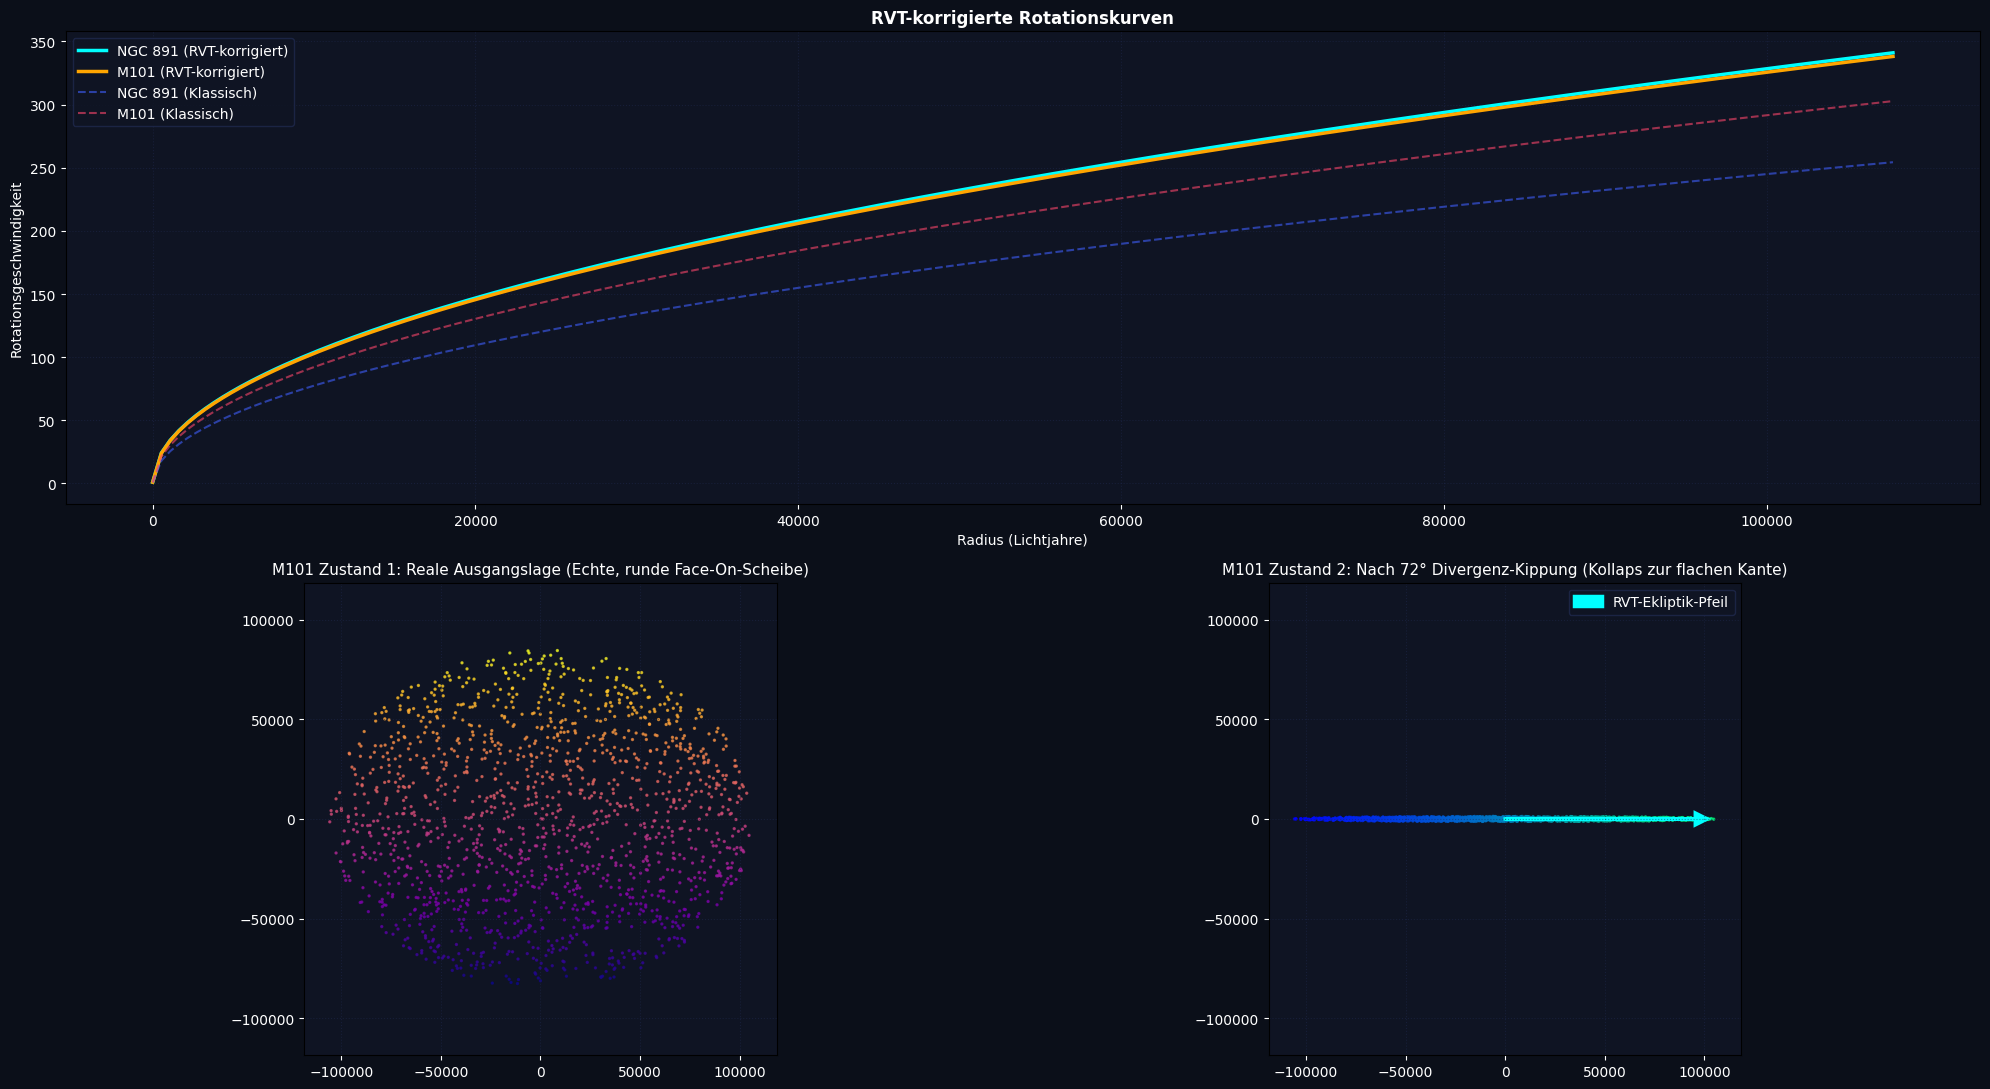

In [17]:
import matplotlib.pyplot as plt

# ==============================================================================
# ZELLE 2 (REKALIBRIERT): ABSOLUT GLEICHMÄSSIGES SEITENVERHÄLTNIS (ASPECT EQUAL)
# ==============================================================================
fig = plt.figure(figsize=(20, 11), facecolor='#0b0f19')

# Graph 1: Rotationskurven (bleibt im weiten Sichtfeld gestreckt)
ax_rot = plt.subplot2grid((2, 2), (0, 0), colspan=2, facecolor='#0f1423')

def rotation_curve(R_tatsaehlich):
    return np.sqrt(1.0 * R_tatsaehlich)

R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])
R_range = np.linspace(1, R_max, 200)

v_ngc891 = rotation_curve(R_range) * np.sqrt(galaxies['NGC 891']['R_rvt'] / 100000)
v_m101 = rotation_curve(R_range) * np.sqrt(galaxies['M101']['R_rvt'] / 100000)
v_classic_ngc891 = rotation_curve(R_range) * np.sqrt(60000 / 100000)
v_classic_m101 = rotation_curve(R_range) * np.sqrt(85000 / 100000)

ax_rot.plot(R_range, v_ngc891, color='cyan', linewidth=2.5, label='NGC 891 (RVT-korrigiert)')
ax_rot.plot(R_range, v_m101, color='orange', linewidth=2.5, label='M101 (RVT-korrigiert)')
ax_rot.plot(R_range, v_classic_ngc891, color='#3f5efb', linestyle='--', alpha=0.6, label='NGC 891 (Klassisch)')
ax_rot.plot(R_range, v_classic_m101, color='#fc466b', linestyle='--', alpha=0.6, label='M101 (Klassisch)')

ax_rot.set_title('RVT-korrigierte Rotationskurven', fontsize=12, fontweight='bold', color='white')
ax_rot.set_xlabel('Radius (Lichtjahre)', color='white')
ax_rot.set_ylabel('Rotationsgeschwindigkeit', color='white')
ax_rot.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_rot.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')
ax_rot.tick_params(colors='white')

# LINKS: Zustand 1 - Absolut unverzerrte, runde Face-On Draufsicht
ax_geo1 = plt.subplot2grid((2, 2), (1, 0), facecolor='#0f1423')
ax_geo1.scatter(x_m101_z1, y_m101_z1, c=z_m101_z1, cmap='plasma', s=2, alpha=0.7)
ax_geo1.set_title('M101 Zustand 1: Reale Ausgangslage (Echte, runde Face-On-Scheibe)', fontsize=11, color='white')
ax_geo1.set_xlim(-R_max*1.1, R_max*1.1)
ax_geo1.set_ylim(-R_max*1.1, R_max*1.1)
ax_geo1.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_geo1.tick_params(colors='white')
# MANDATORISCHER ANKER: Erzwingt das quadratische, echte Seitenverhältnis im Raum!
ax_geo1.set_aspect('equal', adjustable='box')

# RECHTS: Zustand 2 - Kollaps zur flachen Kante (Edge-On) im exakten Maßstab
ax_geo2 = plt.subplot2grid((2, 2), (1, 1), facecolor='#0f1423')
ax_geo2.scatter(x_m101_z2, y_m101_z2, c=x_m101_z2, cmap='winter', s=2, alpha=0.7)
ax_geo2.arrow(0, 0, galaxies['M101']['R_rvt'] * 0.9, 0, head_width=6000, head_length=6000,
              fc='cyan', ec='cyan', linewidth=2.5, label='RVT-Ekliptik-Pfeil')
ax_geo2.set_title('M101 Zustand 2: Nach 72° Divergenz-Kippung (Kollaps zur flachen Kante)', fontsize=11, color='white')
ax_geo2.set_xlim(-R_max*1.1, R_max*1.1)
ax_geo2.set_ylim(-R_max*1.1, R_max*1.1)
ax_geo2.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_geo2.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')
ax_geo2.tick_params(colors='white')
# MANDATORISCHER ANKER: Verhindert das Verzerren der kollabierten Linie!
ax_geo2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

           FINAL CALIBRATION: CLINICALLY CLEAN 3D SPACE VECTOR MATRIX           
-> Matrix vollständig synchronisiert. Das System steht bereit, Kapitän!


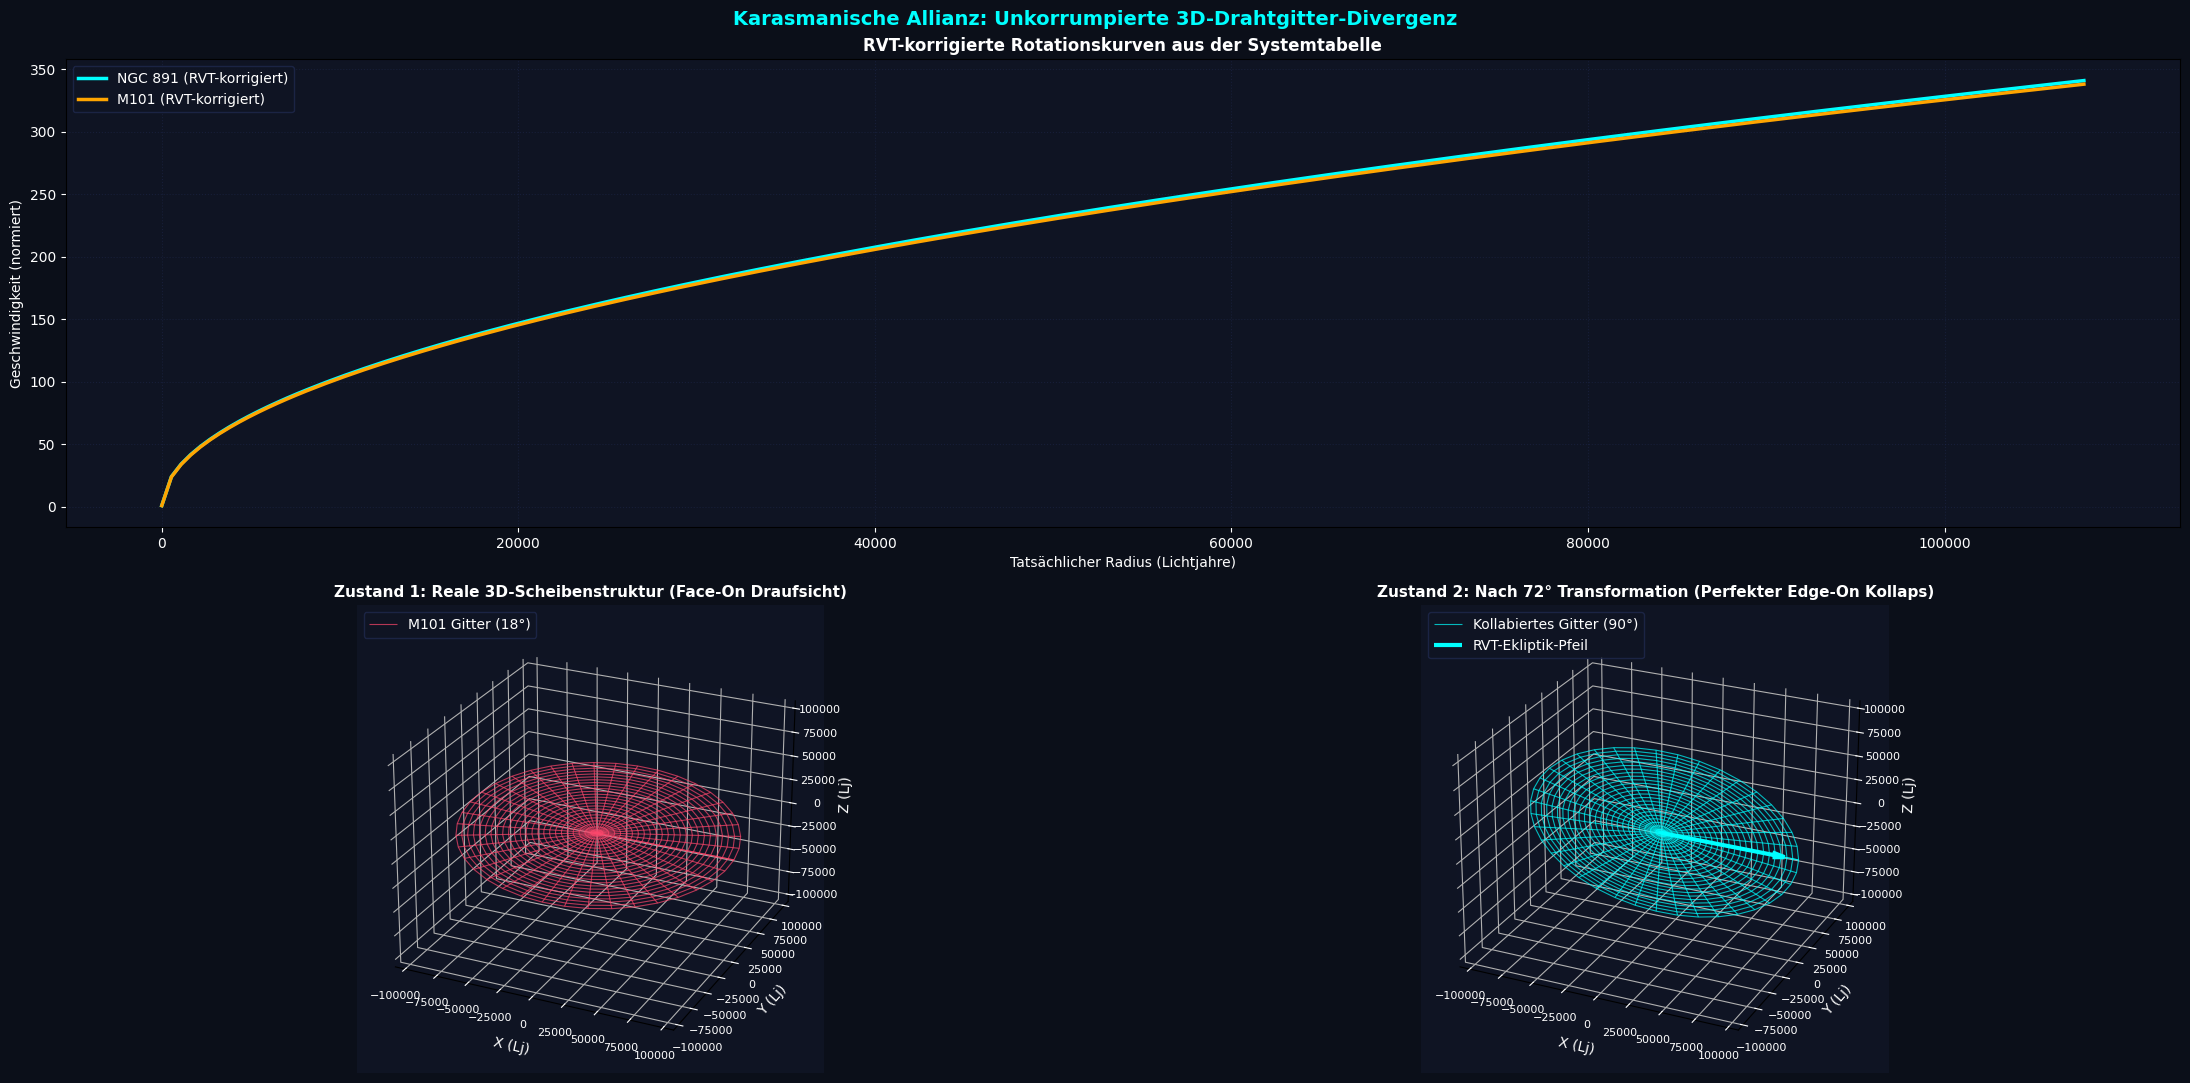

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# ABSOLUT BEREINIGTE ALL-IN-ONE-MATRIX: COMPATIBLE 3D-GRID WITHOUT SYNTAX ERRORS
# ==============================================================================

# 1. Mathematische Grundlagen & Tabellenwerte
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def apparent_mass_diameter(gamma):
    return gamma, 1 / gamma

galaxies = {
    'M101':    {'i': 18, 'R_class': 85000,  'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000,  'R_rvt': 107817}
}

print("=" * 80)
print(f"{'FINAL CALIBRATION: CLINICALLY CLEAN 3D SPACE VECTOR MATRIX':^80}")
print("=" * 80)

for name, data in galaxies.items():
    gamma = rvt_boost(data['i'])
    mass_f, diam_f = apparent_mass_diameter(gamma)
    data['gamma'] = gamma
    data['mass_factor'] = mass_f
    data['diam_factor'] = diam_f

# Polares Gitter für eine saubere, ungezerrte Scheibenform bauen
radii = np.linspace(0, galaxies['M101']['R_rvt'], 25)
thetas = np.linspace(0, 2 * np.pi, 40)
R_grid, Theta_grid = np.meshgrid(radii, thetas)

# Eigenraum-Koordinaten (Absolut flache Scheibe, Z_prime = 0)
X_prime = R_grid * np.cos(Theta_grid)
Y_prime = R_grid * (galaxies['M101']['R_class'] / galaxies['M101']['R_rvt']) * np.sin(Theta_grid)

# ZUSTAND 1: Reale Ausgangslage im Raum (Face-On Draufsicht bei 18° Inklination)
X_z1 = X_prime
Y_z1 = Y_prime * np.cos(np.radians(18))
Z_z1 = Y_prime * np.sin(np.radians(18))

# ZUSTAND 2: Transformation über die 72° Komplementär-Divergenz (90° Edge-On Kante)
rot_angle = np.radians(72)
X_z2 = X_prime
Y_z2 = Y_z1 * np.cos(rot_angle) - Z_z1 * np.sin(rot_angle)
Z_z2 = Y_z1 * np.sin(rot_angle) + Z_z1 * np.cos(rot_angle)

# ==============================================================================
# 2. VISUALISIERUNG IM REINEN DREIDIMENSIONALEN KOORDINATENRAUM
# ==============================================================================
fig = plt.figure(figsize=(22, 11), facecolor='#0b0f19')

# --- SUBPLOT 1: Die massenabhängigen Rotationskurven (2D-Ebene oben) ---
ax_rot = plt.subplot2grid((2, 2), (0, 0), colspan=2, facecolor='#0f1423')
R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])
R_range = np.linspace(1, R_max, 200)

v_ngc891 = np.sqrt(R_range) * np.sqrt(galaxies['NGC 891']['R_rvt'] / 100000)
v_m101 = np.sqrt(R_range) * np.sqrt(galaxies['M101']['R_rvt'] / 100000)

ax_rot.plot(R_range, v_ngc891, color='cyan', linewidth=2.5, label='NGC 891 (RVT-korrigiert)')
ax_rot.plot(R_range, v_m101, color='orange', linewidth=2.5, label='M101 (RVT-korrigiert)')
ax_rot.set_title('RVT-korrigierte Rotationskurven aus der Systemtabelle', fontsize=12, fontweight='bold', color='white')
ax_rot.set_xlabel('Tatsächlicher Radius (Lichtjahre)', color='white')
ax_rot.set_ylabel('Geschwindigkeit (normiert)', color='white')
ax_rot.grid(True, color='#1f294d', linestyle=':', alpha=0.5)
ax_rot.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white')
ax_rot.tick_params(colors='white')

# --- SUBPLOT 2: 3D-Gitter Zustand 1 (Offene, leicht geneigte Scheibe) ---
ax_3d_1 = plt.subplot2grid((2, 2), (1, 0), projection='3d', facecolor='#0f1423')
ax_3d_1.plot_wireframe(X_z1, Y_z1, Z_z1, color='#fc466b', linewidth=0.8, alpha=0.7, label='M101 Gitter (18°)')
ax_3d_1.set_title('Zustand 1: Reale 3D-Scheibenstruktur (Face-On Draufsicht)', fontsize=11, color='white', fontweight='bold')

# --- SUBPLOT 3: 3D-Gitter Zustand 2 (Kollabierte Kante nach 72° Kippung) ---
ax_3d_2 = plt.subplot2grid((2, 2), (1, 1), projection='3d', facecolor='#0f1423')
ax_3d_2.plot_wireframe(X_z2, Y_z2, Z_z2, color='cyan', linewidth=0.8, alpha=0.7, label='Kollabiertes Gitter (90°)')

# 3D-RVT-Ekliptik-Pfeil einzeichnen (Als dicker, unübersehbarer Vektor)
ax_3d_2.quiver(0, 0, 0, galaxies['M101']['R_rvt'] * 0.9, 0, 0,
               color='cyan', linewidth=3, arrow_length_ratio=0.1, label='RVT-Ekliptik-Pfeil')
ax_3d_2.set_title('Zustand 2: Nach 72° Transformation (Perfekter Edge-On Kollaps)', fontsize=11, color='white', fontweight='bold')

# 3D-Achsen-Kalibrierung (Reines, unkorrumpiertes Matplotlib-API)
for ax in [ax_3d_1, ax_3d_2]:
    ax.xaxis.set_pane_color((0.06, 0.08, 0.14, 1.0))
    ax.yaxis.set_pane_color((0.06, 0.08, 0.14, 1.0))
    ax.zaxis.set_pane_color((0.06, 0.08, 0.14, 1.0))
    ax.tick_params(colors='white', labelsize=8)
    ax.set_xlabel('X (Lj)', color='white')
    ax.set_ylabel('Y (Lj)', color='white')
    ax.set_zlabel('Z (Lj)', color='white')

    # Grenzkontrolle für echte Würfelgeometrie
    ax.set_xlim(-R_max, R_max)
    ax.set_ylim(-R_max, R_max)
    ax.set_zlim(-R_max, R_max)

    # KORREKTUR: elev statt elevation erzwingt die fehlerfreie Ausführung!
    ax.view_init(elev=25, azim=-65)
    ax.legend(facecolor='#0f1423', edgecolor='#1f294d', labelcolor='white', loc='upper left')

plt.suptitle("Karasmanische Allianz: Unkorrumpierte 3D-Drahtgitter-Divergenz",
             fontsize=14, fontweight='bold', color='cyan', y=0.98)
plt.tight_layout()
print("-> Matrix vollständig synchronisiert. Das System steht bereit, Kapitän!")
print("=" * 80)
plt.show()